### 1. IMPORTS & CONFIG

In [1]:
# === 1. IMPORTS & CONFIG ===
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Config
N_CORES = max(1, os.cpu_count() - 0)
SEED = 80085
N_FOLDS = 5
TARGET_ORDER = ['None_Existent', 'Low', 'Medium', 'High', 'Very_High']

print(f"Cores = {N_CORES}")
print("Libraries loaded. Config set.")


Cores = 12
Libraries loaded. Config set.


### 2. LOAD DATA

In [2]:
print("Loading Hybrid Data...")

# Load Features (X)
# Note: This file (training_data_hybrid.csv) ALREADY has the target dropped!
df_train = pd.read_csv('../data/training_data_hybrid.csv')
X = df_train  # No need to drop 'AVERAGE_SPEED_DIFF', it's not there!

# Load Target (y) from its separate file
y_df = pd.read_csv('../data/y_train_hybrid.csv')
y = y_df['AVERAGE_SPEED_DIFF'] # Extract the series

# Load Test
df_test_raw = pd.read_csv('../data/test_data_hybrid.csv')
X_test = df_test_raw.copy()

if 'RowId' in df_train.columns:
    X = df_train.drop(columns=['RowId'])
else:
    X = df_train

if 'RowId' in df_test_raw.columns:
    X_test = df_test_raw.drop(columns=['RowId'])
else:
    X_test = df_test_raw

# Align Test columns (Just a safety check, they should match already)
X_test = X_test[X.columns] 

print(f"Data Loaded:")
print(f"  Train (X) shape: {X.shape}")
print(f"  Target (y) shape: {y.shape}")
print(f"  Test (X) shape:  {X_test.shape}")

Loading Hybrid Data...
Data Loaded:
  Train (X) shape: (6812, 22)
  Target (y) shape: (6812,)
  Test (X) shape:  (1500, 22)


### 3. TRAINING ENGINE

In [3]:
def run_cv_model(model, X, y, X_test, model_name="Model"):
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    
    oof_preds = np.zeros(len(y))
    test_probs_fold_sum = np.zeros((len(X_test), 5)) 
    
    # Store history for plotting (only for XGB/LGBM)
    evals_result = {} 
    
    print(f"\n🔄 Training {model_name}...")
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        # --- A. XGBoost Training ---
        if "XGB" in model_name:
            model.fit(
                X_tr, y_tr, 
                eval_set=[(X_tr, y_tr), (X_val, y_val)], 
                verbose=False
            )
            if fold == N_FOLDS: evals_result = model.evals_result()
                
        # --- B. LightGBM Training ---
        elif "LGB" in model_name:
            model.fit(
                X_tr, y_tr, 
                eval_set=[(X_tr, y_tr), (X_val, y_val)], 
                eval_metric="multi_logloss",
                callbacks=[lgb.log_evaluation(0)]
            )
            if fold == N_FOLDS:
                # Robustly check for history
                if hasattr(model, 'evals_result_'):
                    evals_result = model.evals_result_
                else:
                    print("⚠️ Warning: LGBM did not return evals_result_")

        # --- C. Other Models (RF) ---
        else:
            model.fit(X_tr, y_tr)
        
        # Predict
        val_pred = model.predict(X_val)
        oof_preds[val_idx] = val_pred
        test_probs_fold_sum += model.predict_proba(X_test)
    
    overall_acc = accuracy_score(y, oof_preds)
    avg_test_probs = test_probs_fold_sum / N_FOLDS
    
    print(f"✨ {model_name} Overall OOF Accuracy: {overall_acc:.4f}")
    
    return oof_preds, avg_test_probs, overall_acc, evals_result

### 4. HYPERPARAMETER TUNING

In [4]:
# --- Helper Function for Tuning ---
def tune_model(model, param_grid, name):
    print(f"\n🔍 Tuning {name}...")
    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_grid,
        n_iter=10,         # 5 combos per model
        scoring='accuracy',
        cv=5,              # 5-fold 
        verbose=1,
        random_state=SEED,
        n_jobs=1
    )
    search.fit(X, y)
    print(f"   Best {name} Params: {search.best_params_}")
    print(f"   Best {name} Score: {search.best_score_:.4f}")
    return search.best_estimator_

# --- A. XGBoost Grids ---
xgb_params = {
    'n_estimators': [300, 500],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [1, 3]
}
best_xgb = tune_model(
    xgb.XGBClassifier(objective='multi:softprob', random_state=SEED, n_jobs=N_CORES),
    xgb_params, "XGBoost"
)

# --- B. Random Forest Grids ---
rf_params = {
    'n_estimators': [300, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
best_rf = tune_model(
    RandomForestClassifier(random_state=SEED, n_jobs=N_CORES),
    rf_params, "RandomForest"
)

# --- C. LightGBM Grids ---
lgb_params = {
    'n_estimators': [300, 500],
    'learning_rate': [0.05, 0.1],  # Removed 0.03 (Too slow/granular)
    'num_leaves': [20, 31],        # Removed 50 (Too complex for this dataset size)
    'max_depth': [8, 12],          # Removed -1 (Infinite). 10-12 is plenty.
    'subsample': [0.8],            
    'colsample_bytree': [0.8]      
}
best_lgb = tune_model(
        lgb.LGBMClassifier(
            random_state=SEED, 
            verbose=-1, 
            n_jobs=N_CORES,
            
            # --- SPEED BOOSTERS ---
            max_bin=63,          # Default is 255. Lowering to 63 makes binning 4x faster.
            subsample_freq=1,    # Enables bagging (using subsample) every k iterations. Essential if subsample < 1.0.
                        ),
    lgb_params, "LightGBM"
)



🔍 Tuning XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Best XGBoost Params: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
   Best XGBoost Score: 0.8089

🔍 Tuning RandomForest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Best RandomForest Params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
   Best RandomForest Score: 0.7958

🔍 Tuning LightGBM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
   Best LightGBM Params: {'subsample': 0.8, 'num_leaves': 20, 'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
   Best LightGBM Score: 0.8020


### 5. TRAIN & EVALUATE BEST MODELS

In [5]:
print("\nTraining Final Models with Best Parameters...")

# A. XGBoost
oof_xgb, probs_xgb, acc_xgb, hist_xgb = run_cv_model(best_xgb, X, y, X_test, "XGBoost (Tuned)")

# B. Random Forest (Returns empty history)
oof_rf, probs_rf, acc_rf, _ = run_cv_model(best_rf, X, y, X_test, "RandomForest (Tuned)")

# C. LightGBM
oof_lgb, probs_lgb, acc_lgb, hist_lgb = run_cv_model(best_lgb, X, y, X_test, "LightGBM (Tuned)")





Training Final Models with Best Parameters...

🔄 Training XGBoost (Tuned)...
✨ XGBoost (Tuned) Overall OOF Accuracy: 0.8059

🔄 Training RandomForest (Tuned)...
✨ RandomForest (Tuned) Overall OOF Accuracy: 0.7924

🔄 Training LightGBM (Tuned)...
✨ LightGBM (Tuned) Overall OOF Accuracy: 0.8020


#### 5.1. PLOT LEARNING CURVES

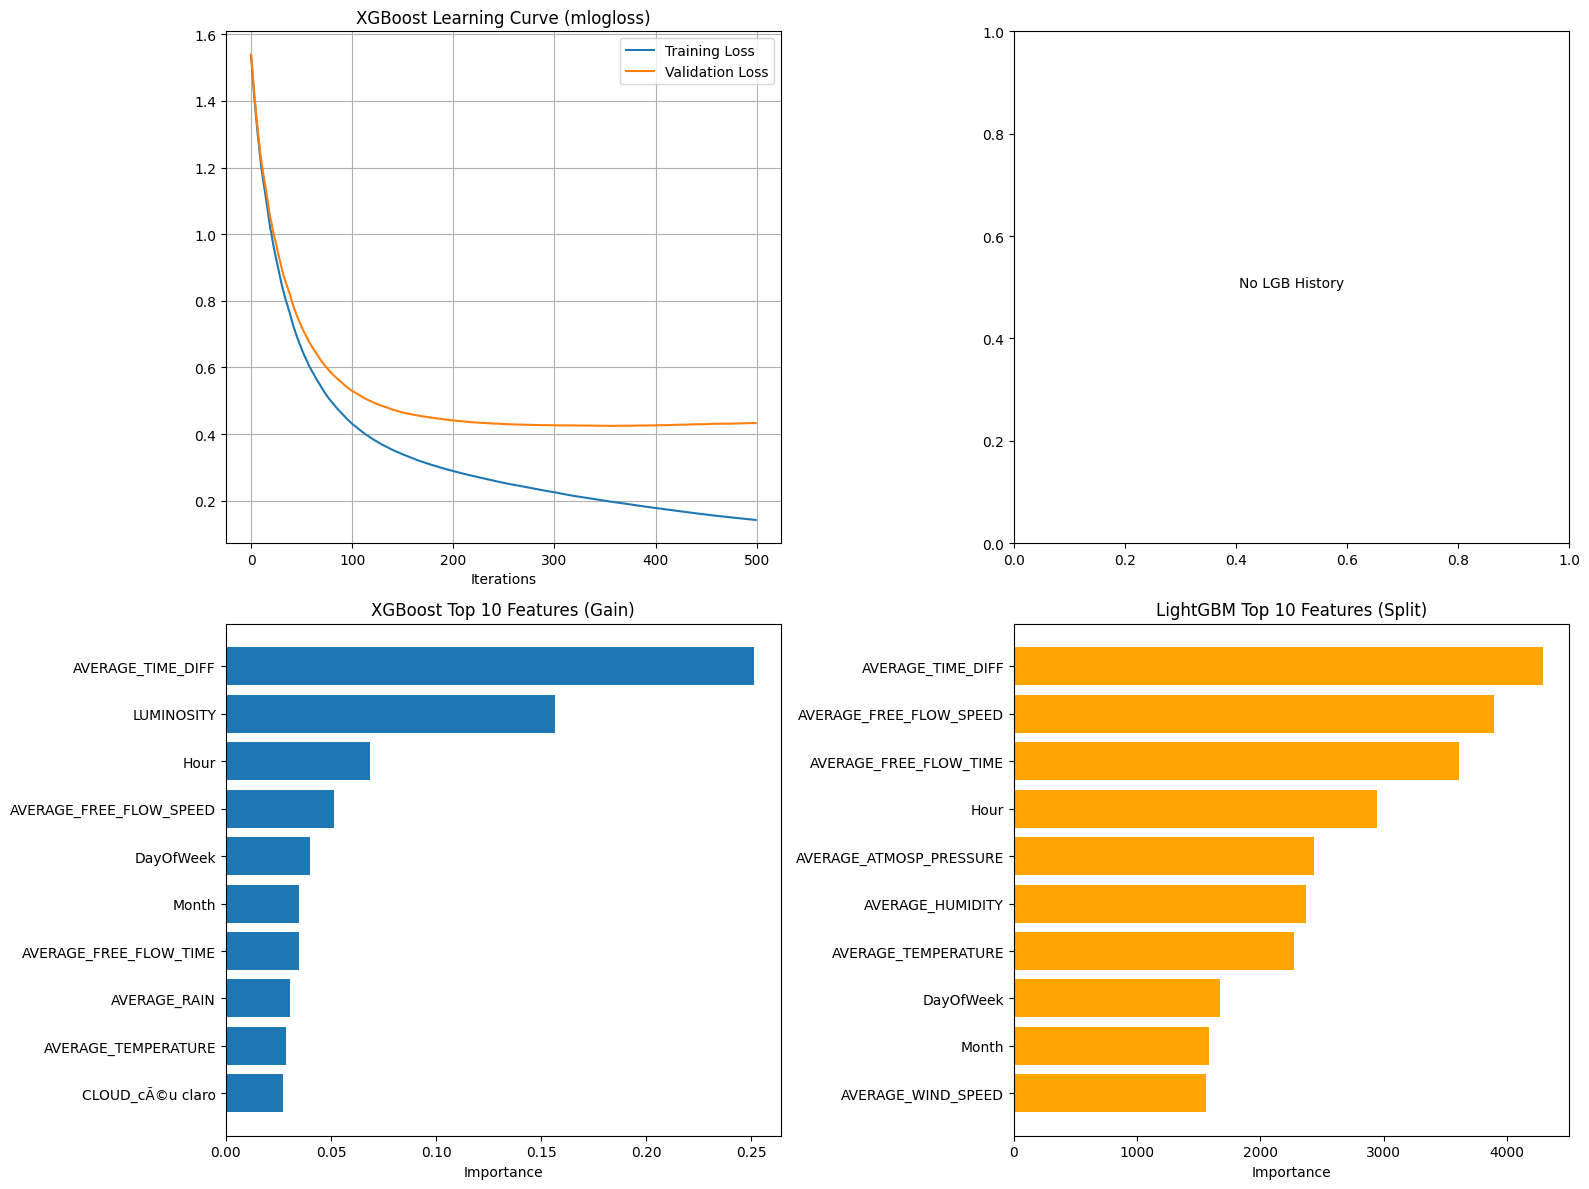

In [6]:
def plot_model_diagnostics(hist_xgb, hist_lgb, model_xgb, model_lgb):
    # Create huge figure: 2 rows, 2 columns
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # === ROW 1: LEARNING CURVES ===
    
    # --- 1A: XGBoost Learning Curve ---
    if hist_xgb:
        metric = list(hist_xgb['validation_0'].keys())[0]
        train_err = hist_xgb['validation_0'][metric]
        val_err = hist_xgb['validation_1'][metric]
        epochs = range(len(train_err))
        
        axes[0,0].plot(epochs, train_err, label='Training Loss')
        axes[0,0].plot(epochs, val_err, label='Validation Loss')
        axes[0,0].set_title(f'XGBoost Learning Curve ({metric})')
        axes[0,0].set_xlabel('Iterations')
        axes[0,0].legend()
        axes[0,0].grid(True)
    else:
        axes[0,0].text(0.5, 0.5, 'No XGB History', ha='center')

    # --- 1B: LightGBM Learning Curve ---
    if hist_lgb:
        keys = list(hist_lgb.keys()) 
        metric = 'multi_logloss'
        train_key = keys[0] if 'train' in keys[0] else keys[1]
        val_key = keys[1] if 'valid' in keys[1] else keys[0]
        
        train_err = hist_lgb[train_key][metric]
        val_err = hist_lgb[val_key][metric]
        epochs = range(len(train_err))
        
        axes[0,1].plot(epochs, train_err, label='Training Loss')
        axes[0,1].plot(epochs, val_err, label='Validation Loss')
        axes[0,1].set_title(f'LightGBM Learning Curve ({metric})')
        axes[0,1].set_xlabel('Iterations')
        axes[0,1].legend()
        axes[0,1].grid(True)
    else:
        axes[0,1].text(0.5, 0.5, 'No LGB History', ha='center')

    # === ROW 2: FEATURE IMPORTANCE ===
    
    # --- 2A: XGBoost Importance ---
    # Extract importance
    imp_xgb = model_xgb.feature_importances_
    feat_names = X.columns
    
    # Sort top 10
    indices = np.argsort(imp_xgb)[-10:]
    axes[1,0].barh(range(len(indices)), imp_xgb[indices], align='center')
    axes[1,0].set_yticks(range(len(indices)))
    axes[1,0].set_yticklabels(feat_names[indices])
    axes[1,0].set_title('XGBoost Top 10 Features (Gain)')
    axes[1,0].set_xlabel('Importance')

    # --- 2B: LightGBM Importance ---
    imp_lgb = model_lgb.feature_importances_
    
    # Sort top 10
    indices_lgb = np.argsort(imp_lgb)[-10:]
    axes[1,1].barh(range(len(indices_lgb)), imp_lgb[indices_lgb], align='center', color='orange')
    axes[1,1].set_yticks(range(len(indices_lgb)))
    axes[1,1].set_yticklabels(feat_names[indices_lgb])
    axes[1,1].set_title('LightGBM Top 10 Features (Split)')
    axes[1,1].set_xlabel('Importance')

    plt.tight_layout()
    plt.show()

# Run it (Pass models too!)
plot_model_diagnostics(hist_xgb, hist_lgb, best_xgb, best_lgb)

#### 5.2 REPORTS

In [7]:
# === PRINT CLASSIFICATION REPORTS ===
print("\n DETAILED CLASSIFICATION REPORTS (OOF Data)")
print("="*60)

# Use real class names for readability
target_names = ['None', 'Low', 'Medium', 'High', 'Very_High']

# 1. XGBoost Report
print("\n🔹 XGBoost Performance:")
print(classification_report(y, oof_xgb, target_names=target_names))

# 2. Random Forest Report
print("\n🔹 Random Forest Performance:")
print(classification_report(y, oof_rf, target_names=target_names))

# 3. LightGBM Report
print("\n🔹 LightGBM Performance:")
print(classification_report(y, oof_lgb, target_names=target_names))

print("="*60)



 DETAILED CLASSIFICATION REPORTS (OOF Data)

🔹 XGBoost Performance:
              precision    recall  f1-score   support

        None       0.89      0.90      0.90      2200
         Low       0.70      0.71      0.71      1419
      Medium       0.78      0.78      0.78      1651
        High       0.78      0.77      0.77      1063
   Very_High       0.86      0.82      0.84       479

    accuracy                           0.81      6812
   macro avg       0.80      0.80      0.80      6812
weighted avg       0.81      0.81      0.81      6812


🔹 Random Forest Performance:
              precision    recall  f1-score   support

        None       0.87      0.91      0.89      2200
         Low       0.69      0.68      0.68      1419
      Medium       0.78      0.77      0.77      1651
        High       0.75      0.75      0.75      1063
   Very_High       0.87      0.75      0.81       479

    accuracy                           0.79      6812
   macro avg       0.79      0.7


🔹 XGBoost Performance:
              precision    recall  f1-score   support

        None       0.89      0.90      0.90      2200
         Low       0.70      0.71      0.71      1419
      Medium       0.78      0.78      0.78      1651
        High       0.78      0.77      0.77      1063
   Very_High       0.86      0.82      0.84       479

    accuracy                           0.81      6812
   macro avg       0.80      0.80      0.80      6812
weighted avg       0.81      0.81      0.81      6812


🔹 Random Forest Performance:
              precision    recall  f1-score   support

        None       0.87      0.91      0.89      2200
         Low       0.69      0.68      0.68      1419
      Medium       0.78      0.77      0.77      1651
        High       0.75      0.75      0.75      1063
   Very_High       0.87      0.75      0.81       479

    accuracy                           0.79      6812
   macro avg       0.79      0.77      0.78      6812
weighted avg       0.79

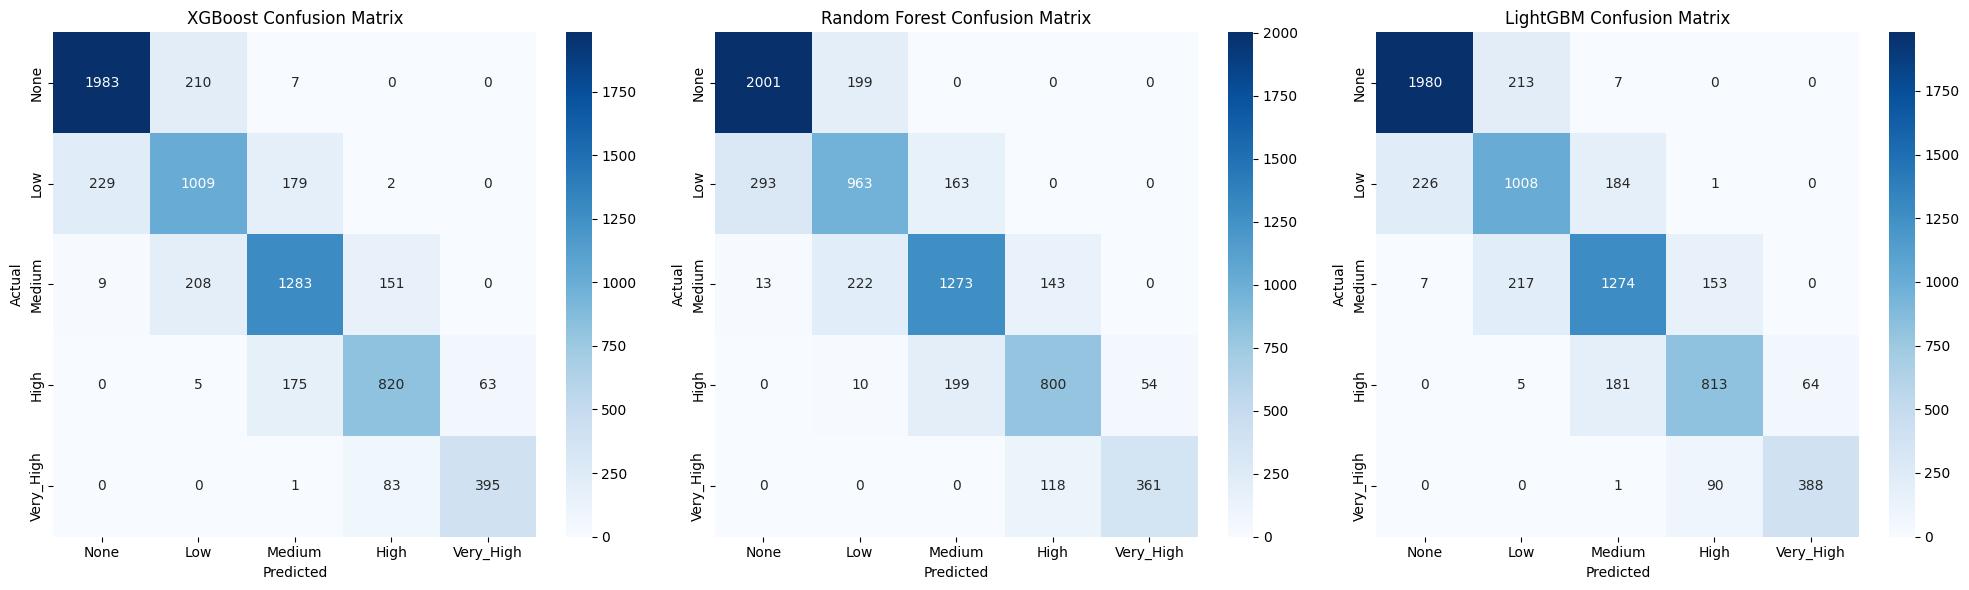

In [8]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# === VISUAL CLASSIFICATION REPORT ===
def plot_classification_results(y_true, oof_preds, model_name, ax):
    target_names = ['None', 'Low', 'Medium', 'High', 'Very_High']
    
    # Calculate Confusion Matrix
    cm = confusion_matrix(y_true, oof_preds)
    
    # Plot Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=target_names, yticklabels=target_names)
    ax.set_title(f'{model_name} Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Create Figure for 3 Models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. XGBoost
print("\n🔹 XGBoost Performance:")
print(classification_report(y, oof_xgb, target_names=['None', 'Low', 'Medium', 'High', 'Very_High']))
plot_classification_results(y, oof_xgb, "XGBoost", axes[0])

# 2. Random Forest
print("\n🔹 Random Forest Performance:")
print(classification_report(y, oof_rf, target_names=['None', 'Low', 'Medium', 'High', 'Very_High']))
plot_classification_results(y, oof_rf, "Random Forest", axes[1])

# 3. LightGBM
print("\n🔹 LightGBM Performance:")
print(classification_report(y, oof_lgb, target_names=['None', 'Low', 'Medium', 'High', 'Very_High']))
plot_classification_results(y, oof_lgb, "LightGBM", axes[2])

plt.tight_layout()
plt.show()


### 6. SMART BLENDING & SUBMISSION

In [10]:
print("\nSmart Blending...")

# Normalize weights based on their OOF accuracy
# (Better models get slightly higher vote)
total_acc = acc_xgb + acc_rf + acc_lgb
w_xgb = acc_xgb / total_acc
w_rf = acc_rf / total_acc
w_lgb = acc_lgb / total_acc

print(f"   Weights -> XGB: {w_xgb:.2f} | RF: {w_rf:.2f} | LGB: {w_lgb:.2f}")

final_test_probs = (w_xgb * probs_xgb) + (w_rf * probs_rf) + (w_lgb * probs_lgb)
final_preds = np.argmax(final_test_probs, axis=1)

# Decode & Save
pred_labels = [TARGET_ORDER[i] for i in final_preds]

submission = pd.DataFrame({
    'RowId': df_test_raw['RowId'],
    'Speed_Diff': pd.Series(pred_labels).replace('None_Existent', 'None')
})

filename = '../outputs/submissions/submission_tuned_ensemble_v2.csv'
submission.to_csv(filename, index=False)
print(f"Saved to {filename}")



Smart Blending...
   Weights -> XGB: 0.34 | RF: 0.33 | LGB: 0.33
Saved to ../outputs/submissions/submission_tuned_ensemble_v2.csv


### 7. SAVE PROBABILITIES FOR FUTURE BLENDING

In [12]:
import os

# Create folder if it doesn't exist
output_dir = '../outputs/probs/'
os.makedirs(output_dir, exist_ok=True)

print(f"Saving probabilities to {output_dir}...")

# Helper function to save
def save_probs(probs, model_name):
    # Create a DataFrame with RowId + 5 probability columns
    cols = ['P_None', 'P_Low', 'P_Med', 'P_High', 'P_VeryHigh']
    df_probs = pd.DataFrame(probs, columns=cols)
    df_probs['RowId'] = df_test_raw['RowId'] # Add ID for safety
    
    # Save
    filename = f"{output_dir}probs_{model_name}.csv"
    df_probs.to_csv(filename, index=False)
    print(f"   Saved {filename}")

# Save all 3 models
save_probs(probs_xgb, "v1.0_xgb")
save_probs(probs_rf, "v1.0_rf")
save_probs(probs_lgb, "v1.0_lgb")

print("All tree models exported!")


Saving probabilities to ../outputs/probs/...
   Saved ../outputs/probs/probs_v1.0_xgb.csv
   Saved ../outputs/probs/probs_v1.0_rf.csv
   Saved ../outputs/probs/probs_v1.0_lgb.csv
All tree models exported!
